In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

from notebook_utils import bootstrap_mean_and_ci

In [2]:
def prepend_ones(arr):
    ones = np.ones((arr.shape[0], 1))
    return np.hstack((ones, arr))

def load_vision_method_soft(model, method):
    with open(f"../scripts/_cache/{model}_imagenet_2_per_class_{method}_soft_stability_rates.json") as f:
        return prepend_ones(np.array(json.load(f)["soft_stability_rates"]))

def load_vision_method_hard(model, method):
    with open(f"../scripts/_cache/{model}_imagenet_2_per_class_{method}_hard_stability_radii.json") as f:
        l2r = json.load(f)["lambda_to_radii"]
        return {lambda_: np.array(l2r[lambda_]) for lambda_ in ["0.125", "0.250", "0.375", "0.500"]}

methods = ["lime", "shap", "intgrad", "mfaba", "random"]
vit_soft_rates = {m: load_vision_method_soft("vit", m) for m in methods}
resnet50_soft_rates = {m: load_vision_method_soft("resnet50", m) for m in methods}
resnet18_soft_rates = {m: load_vision_method_soft("resnet18", m) for m in methods}

vit_hard_radii = {m: load_vision_method_hard("vit", m) for m in methods}
resnet50_hard_radii = {m: load_vision_method_hard("resnet50", m) for m in methods}
resnet18_hard_radii = {m: load_vision_method_hard("resnet18", m) for m in methods}

In [3]:
def right_padded(lists):
    max_len = max(len(ls) for ls in lists)
    padded_array = np.array([ls + [0] * (max_len - len(ls)) for ls in lists])
    return padded_array

def load_roberta_task_method_soft(task, method):
    with open(f"../scripts/_cache/roberta_tweeteval_{task}_{method}_soft_stability_rates.json") as f:
        return prepend_ones(right_padded(json.load(f)["soft_stability_rates"]))

def load_roberta_task_method_hard(task, method):
    with open(f"../scripts/_cache/roberta_tweeteval_{task}_{method}_hard_stability_radii.json") as f:
        l2r = json.load(f)["lambda_to_radii"]
        return {lambda_: np.array(l2r[lambda_]) for lambda_ in ["0.125", "0.250", "0.375", "0.500"]}

In [4]:
roberta_emoji_soft_rates = {m: load_roberta_task_method_soft("emoji", m) for m in methods}
roberta_emotion_soft_rates = {m: load_roberta_task_method_soft("emotion", m) for m in methods}
roberta_hate_soft_rates = {m: load_roberta_task_method_soft("hate", m) for m in methods}
roberta_irony_soft_rates = {m: load_roberta_task_method_soft("irony", m) for m in methods}
roberta_offensive_soft_rates = {m: load_roberta_task_method_soft("offensive", m) for m in methods}
roberta_sentiment_soft_rates = {m: load_roberta_task_method_soft("sentiment", m) for m in methods}

roberta_all_soft_rates = {
    m: np.vstack([
        roberta_emoji_soft_rates[m],
        roberta_emotion_soft_rates[m],
        roberta_hate_soft_rates[m],
        roberta_irony_soft_rates[m],
        roberta_offensive_soft_rates[m],
        roberta_sentiment_soft_rates[m]
    ])
    for m in methods
}

roberta_emoji_hard_radii = {m: load_roberta_task_method_hard("emoji", m) for m in methods}
roberta_emotion_hard_radii = {m: load_roberta_task_method_hard("emotion", m) for m in methods}
roberta_hate_hard_radii = {m: load_roberta_task_method_hard("hate", m) for m in methods}
roberta_irony_hard_radii = {m: load_roberta_task_method_hard("irony", m) for m in methods}
roberta_offensive_hard_radii = {m: load_roberta_task_method_hard("offensive", m) for m in methods}
roberta_sentiment_hard_radii = {m: load_roberta_task_method_hard("sentiment", m) for m in methods}

roberta_all_hard_radii = {
    m : {
        lambda_: np.concatenate([
            roberta_emoji_hard_radii[m][lambda_],
            roberta_emotion_hard_radii[m][lambda_],
            roberta_hate_hard_radii[m][lambda_],
            roberta_irony_hard_radii[m][lambda_],
            roberta_offensive_hard_radii[m][lambda_],
            roberta_sentiment_hard_radii[m][lambda_],
        ])
        for lambda_ in ["0.125", "0.250", "0.375", "0.500"]
    }
    for m in methods
}

In [5]:
def plot_soft_rates(model_rates, radii, title, legend_loc=None, fs=16, plot_ci=True, xticks=None):
    fig, ax = plt.subplots(figsize=(4,3))
    
    mean, lb, ub = bootstrap_mean_and_ci(model_rates["lime"])
    ax.plot(radii, mean, label="LIME")

    if plot_ci:
        ax.fill_between(radii, lb, ub, alpha=0.2)
    
    mean, lb, ub = bootstrap_mean_and_ci(model_rates["shap"])
    ax.plot(radii, mean, label="SHAP")
    if plot_ci:
        ax.fill_between(radii, lb, ub, alpha=0.2)

    mean, lb, ub = bootstrap_mean_and_ci(model_rates["intgrad"])
    ax.plot(radii, mean, label="IntGrad")
    if plot_ci:
        ax.fill_between(radii, lb, ub, alpha=0.2)

    mean, lb, ub = bootstrap_mean_and_ci(model_rates["mfaba"])
    ax.plot(radii, mean, label="MFABA")
    if plot_ci:
        ax.fill_between(radii, lb, ub, alpha=0.2)

    mean, lb, ub = bootstrap_mean_and_ci(model_rates["random"])
    ax.plot(radii, mean,label="Random")
    if plot_ci:
        ax.fill_between(radii, lb, ub, alpha=0.2)

    # ax.set_ylim(0.0, 1.05)
    ax.set_xlabel("Perturbation Radius", fontsize=fs)
    ax.set_ylabel("Soft Stability Rate", fontsize=fs)
    ax.tick_params(axis="both", labelsize=fs)
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.legend(title=title, loc=legend_loc, title_fontsize=fs, fontsize=fs-2)
    return fig

In [6]:
image_radii = [0, 1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 147]
text_radii = list(range(21))

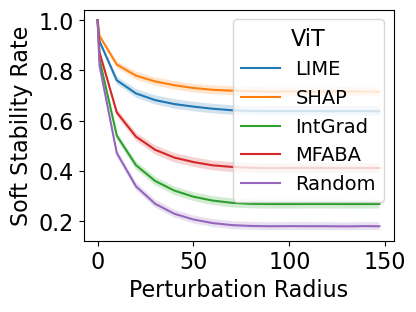

In [7]:
fig = plot_soft_rates(vit_soft_rates, image_radii, "ViT", legend_loc="upper right")
fig.savefig("_dump/soft_vs_method_vit_imagenet_2_per_class.pdf", bbox_inches="tight")

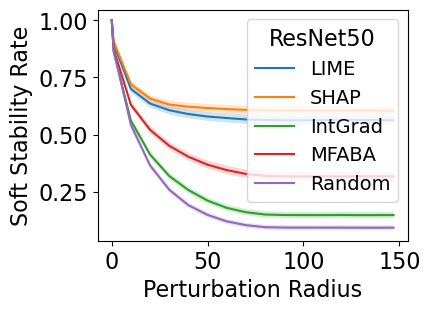

In [8]:
fig = plot_soft_rates(resnet50_soft_rates, image_radii, "ResNet50", legend_loc="upper right")
fig.savefig("_dump/soft_vs_method_resnet50_imagenet_2_per_class.pdf", bbox_inches="tight")

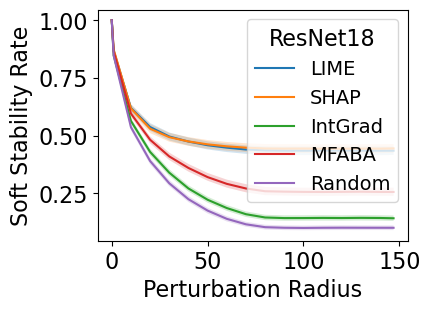

In [9]:
fig = plot_soft_rates(resnet18_soft_rates, image_radii, "ResNet18", legend_loc="upper right")
fig.savefig("_dump/soft_vs_method_resnet18_imagenet_2_per_class.pdf", bbox_inches="tight")

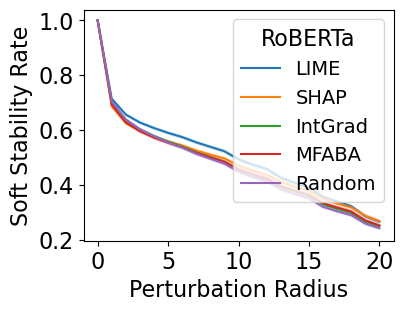

In [10]:
fig = plot_soft_rates(roberta_all_soft_rates, text_radii, "RoBERTa", xticks=[0, 5, 10, 15, 20])
fig.savefig("_dump/soft_vs_method_roberta_tweeteval_all.pdf", bbox_inches="tight")

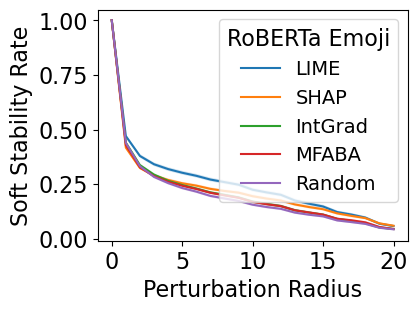

In [11]:
fig = plot_soft_rates(roberta_emoji_soft_rates, text_radii, "RoBERTa Emoji", xticks=[0, 5, 10, 15, 20])
fig.savefig("_dump/soft_vs_method_roberta_tweeteval_emoji.pdf", bbox_inches="tight")

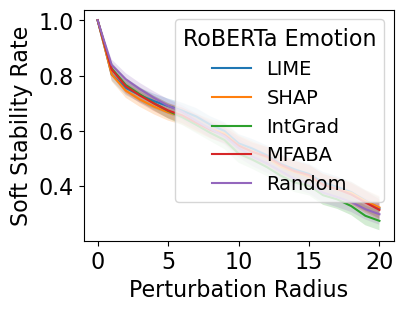

In [12]:
fig = plot_soft_rates(roberta_emotion_soft_rates, text_radii, "RoBERTa Emotion", xticks=[0, 5, 10, 15, 20])
fig.savefig("_dump/soft_vs_method_roberta_tweeteval_emotion.pdf", bbox_inches="tight")

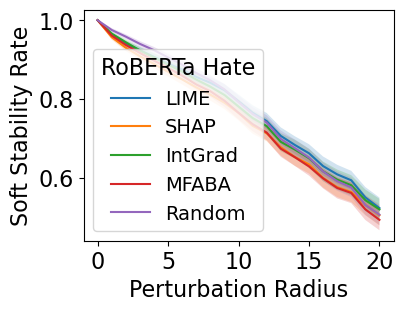

In [13]:
fig = plot_soft_rates(roberta_hate_soft_rates, text_radii, "RoBERTa Hate", xticks=[0, 5, 10, 15, 20])
fig.savefig("_dump/soft_vs_method_roberta_tweeteval_hate.pdf", bbox_inches="tight")

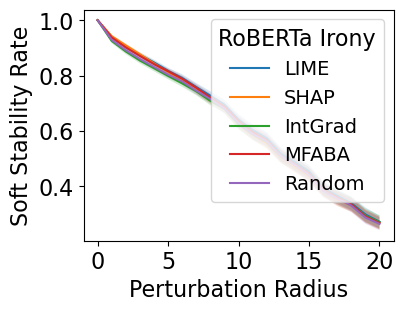

In [14]:
fig = plot_soft_rates(roberta_irony_soft_rates, text_radii, "RoBERTa Irony", xticks=[0, 5, 10, 15, 20])
fig.savefig("_dump/soft_vs_method_roberta_tweeteval_irony.pdf", bbox_inches="tight")

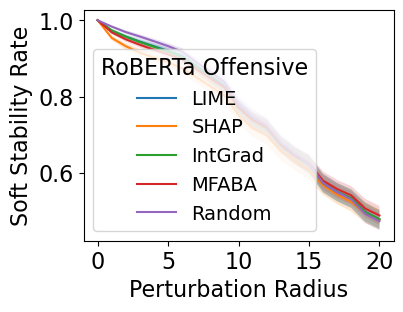

In [15]:
fig = plot_soft_rates(roberta_offensive_soft_rates, text_radii, "RoBERTa Offensive", xticks=[0, 5, 10, 15, 20])
fig.savefig("_dump/soft_vs_method_roberta_tweeteval_offensive.pdf", bbox_inches="tight")

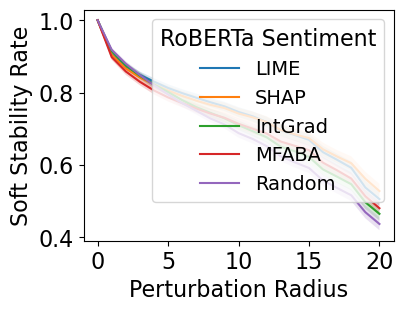

In [16]:
fig = plot_soft_rates(roberta_sentiment_soft_rates, text_radii, "RoBERTa Sentiment", xticks=[0, 5, 10, 15, 20])
fig.savefig("_dump/soft_vs_method_roberta_tweeteval_sentiment.pdf", bbox_inches="tight")

In [17]:
vit_hard_radii

{'lime': {'0.125': array([1.6875, 0.1875, 0.375 , ..., 0.375 , 0.75  , 0.0625]),
  '0.250': array([0.40625, 0.1875 , 0.     , ..., 0.09375, 0.46875, 0.15625]),
  '0.375': array([0.16666667, 0.29166669, 0.0625    , ..., 0.3125    , 0.10416667,
         0.14583334]),
  '0.500': array([0.390625, 0.046875, 0.171875, ..., 0.25    , 0.015625, 0.      ])},
 'shap': {'0.125': array([0.    , 0.75  , 0.625 , ..., 0.1875, 0.0625, 0.125 ]),
  '0.250': array([0.09375, 0.28125, 0.03125, ..., 0.09375, 0.59375, 0.25   ]),
  '0.375': array([0.02083333, 0.08333334, 0.16666667, ..., 0.04166667, 0.33333334,
         0.04166667]),
  '0.500': array([0.828125, 0.6875  , 0.046875, ..., 0.      , 0.1875  , 0.0625  ])},
 'intgrad': {'0.125': array([2.375 , 0.8125, 0.    , ..., 0.25  , 0.5   , 0.125 ]),
  '0.250': array([0.875  , 0.0625 , 0.21875, ..., 0.15625, 0.03125, 0.125  ]),
  '0.375': array([0.02083333, 0.10416667, 0.14583334, ..., 0.08333334, 0.1875    ,
         0.0625    ]),
  '0.500': array([0.125   ,

In [18]:
def plot_hard_rates_by_lambda(radii_dict, lambda_: str, title, legend_loc=None, fs=16, max_radius=4.0, xticks=None):
    fig, ax = plt.subplots(figsize=(4,3))

    r_ticks = np.linspace(0.0, max_radius, num=1000)
    cert_rs = np.array([(radii_dict["lime"][lambda_] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="LIME")
    # ax.plot(r_ticks, cert_rs)

    cert_rs = np.array([(radii_dict["shap"][lambda_] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="SHAP")
    # ax.plot(r_ticks, cert_rs)
    
    cert_rs = np.array([(radii_dict["intgrad"][lambda_] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="IntGrad")
    # ax.plot(r_ticks, cert_rs)

    cert_rs = np.array([(radii_dict["mfaba"][lambda_] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="MFABA")
    # ax.plot(r_ticks, cert_rs)
    
    cert_rs = np.array([(radii_dict["random"][lambda_] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="Random")
    # ax.plot(r_ticks, cert_rs)

    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel("Perturbation Radius", fontsize=fs)
    ax.set_ylabel("Hard Stability Rate", fontsize=fs)
    ax.tick_params(axis="both", labelsize=fs)

    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xlim(0.0, xticks[-1] + 0.05)
    else:
        ax.set_xticks([0, 1, 2, 3, 4])
        ax.set_xlim(0.0, 4.05)

    ax.legend(title=title, loc=legend_loc, title_fontsize=fs, fontsize=fs-2)
    return fig

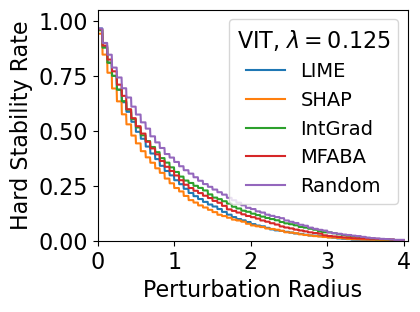

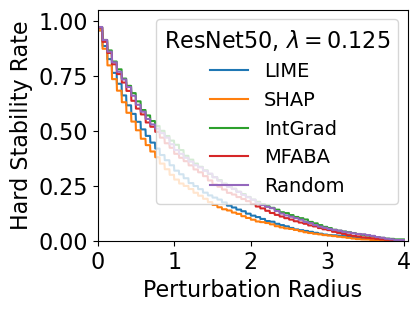

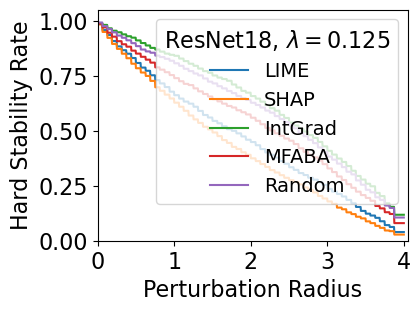

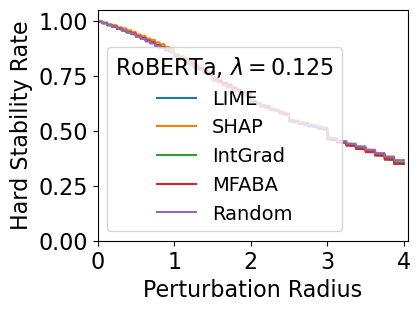

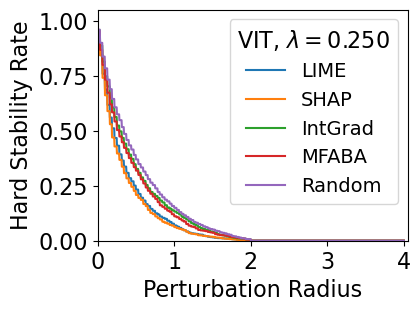

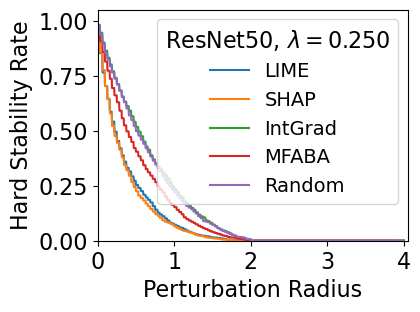

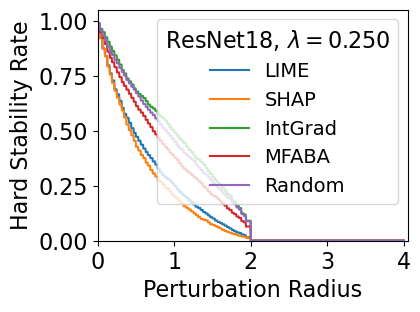

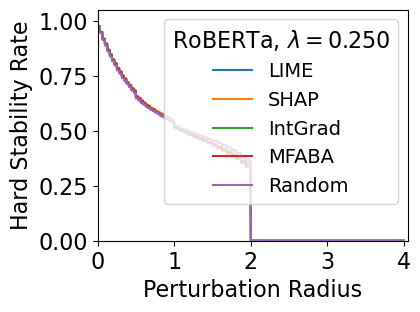

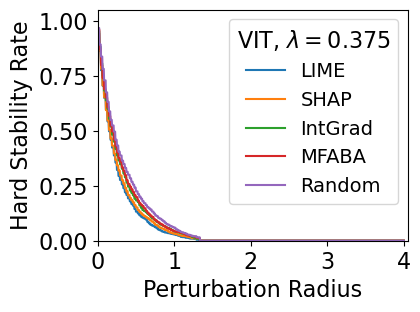

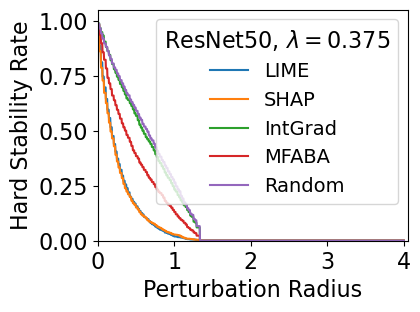

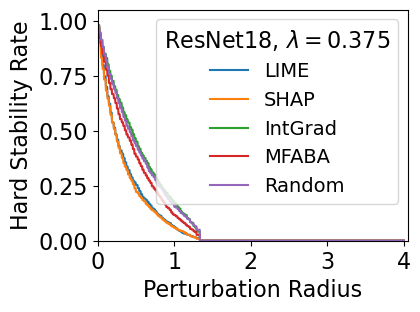

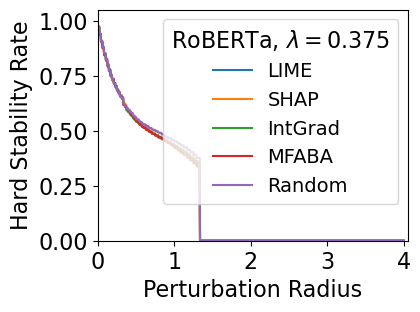

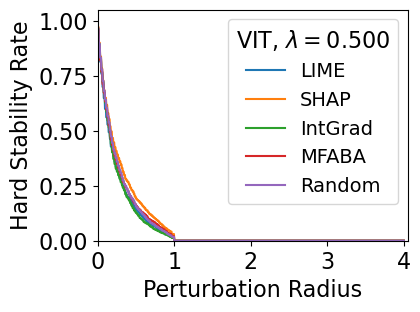

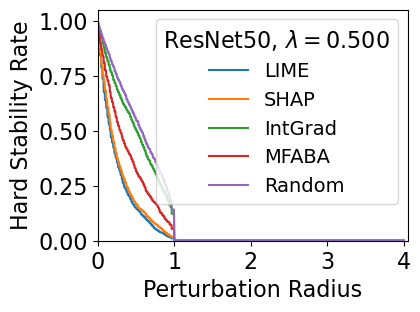

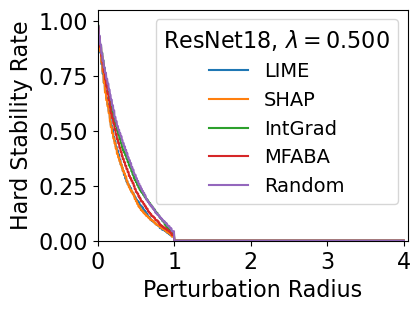

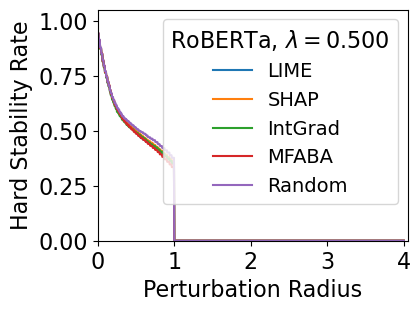

In [19]:
for lambda_ in ["0.125", "0.250", "0.375", "0.500"]:    
    fig = plot_hard_rates_by_lambda(vit_hard_radii, lambda_, f"VIT, $\lambda = {lambda_}$")
    fig.show()
    fig.savefig(f"_dump/hard_vs_lambda_vit_imagenet_2_per_class_{lambda_}.pdf", bbox_inches="tight")

    fig = plot_hard_rates_by_lambda(resnet50_hard_radii, lambda_, f"ResNet50, $\lambda = {lambda_}$")
    fig.show()
    fig.savefig(f"_dump/hard_vs_lambda_resnet50_imagenet_2_per_class_{lambda_}.pdf", bbox_inches="tight")
    
    fig = plot_hard_rates_by_lambda(resnet18_hard_radii, lambda_, f"ResNet18, $\lambda = {lambda_}$")
    fig.show()
    fig.savefig(f"_dump/hard_vs_lambda_resnet18_imagenet_2_per_class_{lambda_}.pdf", bbox_inches="tight")

    fig = plot_hard_rates_by_lambda(roberta_all_hard_radii, lambda_, f"RoBERTa, $\lambda = {lambda_}$")
    fig.show()
    fig.savefig(f"_dump/hard_vs_lambda_roberta_tweeteval_all_{lambda_}.pdf", bbox_inches="tight")

In [20]:
def plot_hard_rates_by_method(radii_dict, method, title, legend_loc=None, fs=16, xticks=None):
    fig, ax = plt.subplots(figsize=(4,3))
    r_max = 4
    r_ticks = np.linspace(0.0, r_max, num=1000)
    
    cert_rs = np.array([(radii_dict[method]["0.125"] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="$\lambda = 0.125$")
    
    cert_rs = np.array([(radii_dict[method]["0.250"] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="$\lambda = 0.250$")
    
    cert_rs = np.array([(radii_dict[method]["0.375"] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="$\lambda = 0.375$")
    
    cert_rs = np.array([(radii_dict[method]["0.500"] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="$\lambda = 0.500$")

    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel("Perturbation Radius", fontsize=fs)
    ax.set_ylabel("Hard Stability Rate", fontsize=fs)
    ax.tick_params(axis="both", labelsize=fs)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xlim(0.0, xticks[-1] + 0.05)
    else:
        ax.set_xticks([0, 1.0, 2.0, 3.0, 4.0])
        ax.set_xlim(0.0, 4.05)
    ax.legend(title=title, loc=legend_loc, title_fontsize=fs, fontsize=fs)
    return fig

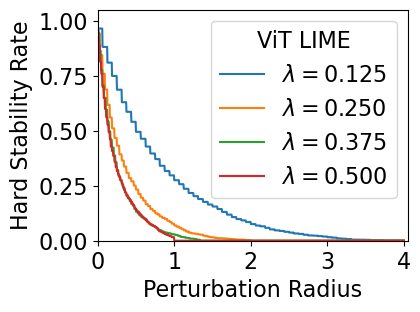

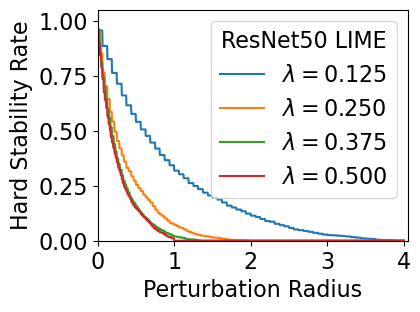

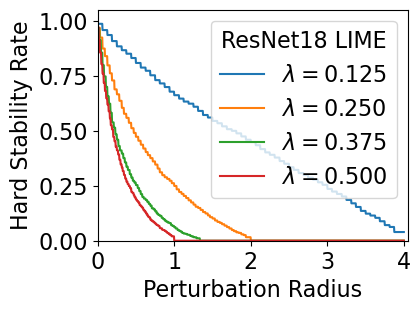

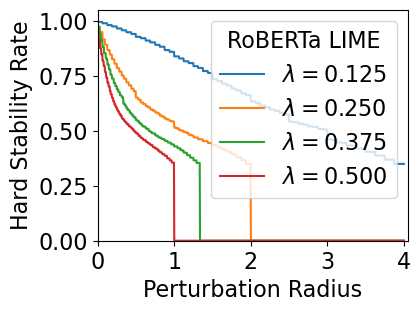

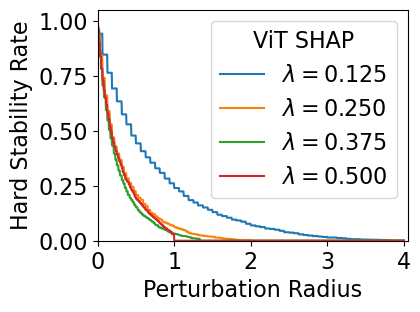

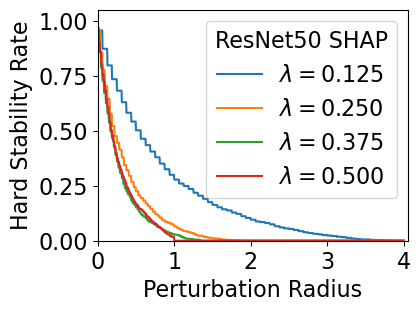

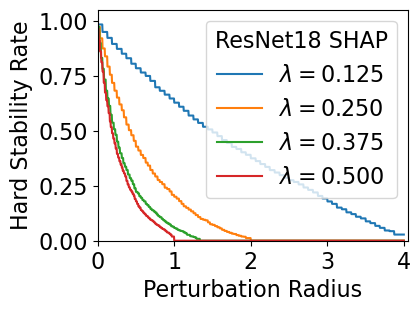

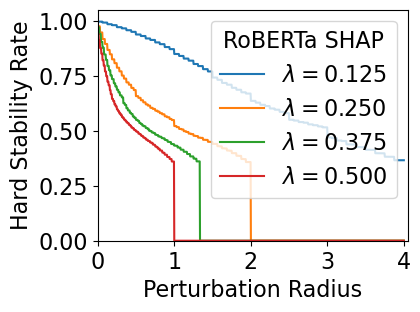

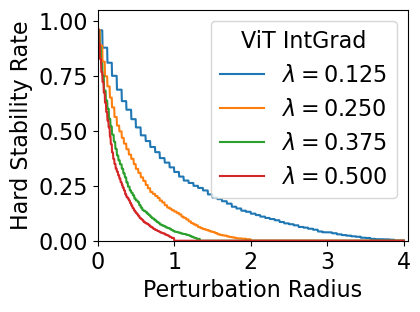

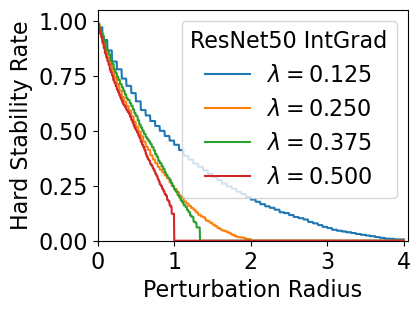

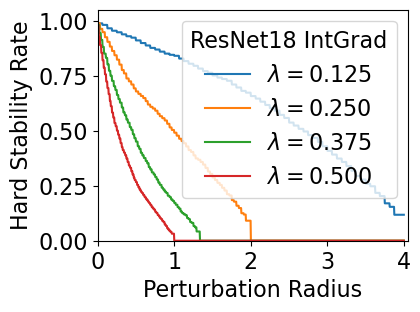

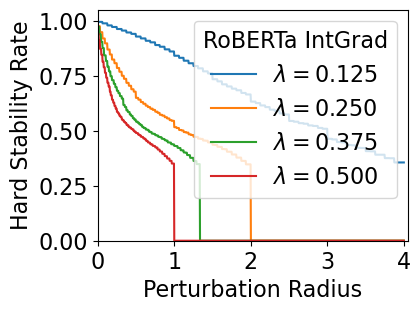

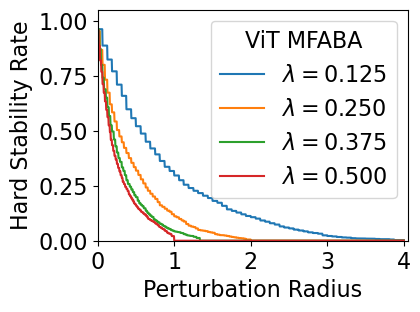

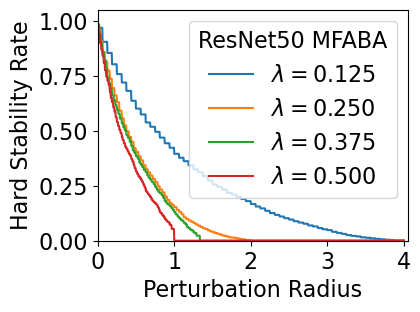

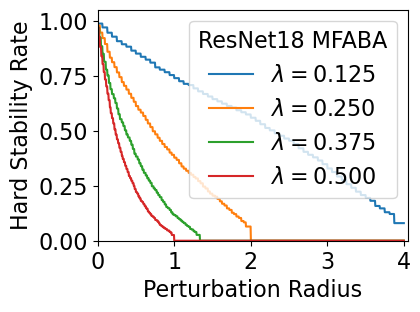

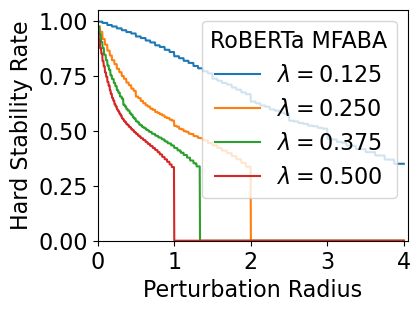

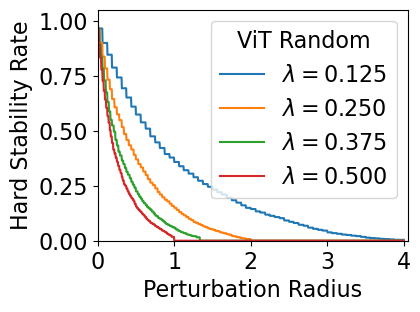

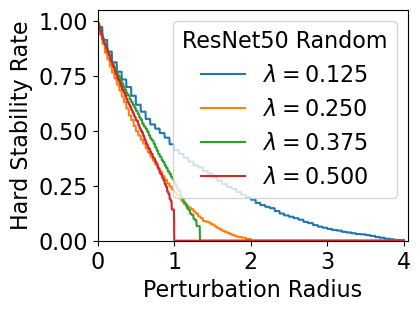

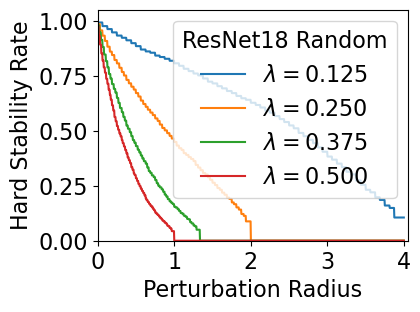

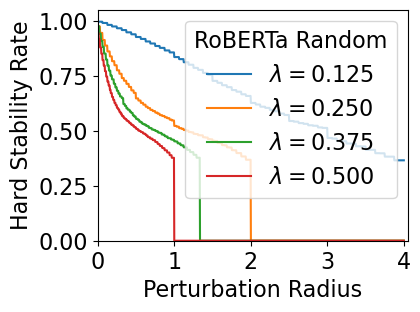

In [21]:
for method, title in [("lime", "LIME"), ("shap", "SHAP"), ("intgrad", "IntGrad"), ("mfaba", "MFABA"), ("random", "Random")]:
    fig = plot_hard_rates_by_method(vit_hard_radii, method, "ViT " + title)
    fig.show()
    fig.savefig(f"_dump/hard_vs_method_vit_imagenet_2_per_class_{method}.pdf", bbox_inches="tight")

    fig = plot_hard_rates_by_method(resnet50_hard_radii, method, "ResNet50 " + title)
    fig.show()
    fig.savefig(f"_dump/hard_vs_method_resnet50_imagenet_2_per_class_{method}.pdf", bbox_inches="tight")

    fig = plot_hard_rates_by_method(resnet18_hard_radii, method, "ResNet18 " + title)
    fig.show()
    fig.savefig(f"_dump/hard_vs_method_resnet18_imagenet_2_per_class_{method}.pdf", bbox_inches="tight")

    fig = plot_hard_rates_by_method(roberta_all_hard_radii, method, "RoBERTa " + title)
    fig.show()
    fig.savefig(f"_dump/hard_vs_method_roberta_tweeteval_all_{method}.pdf", bbox_inches="tight")

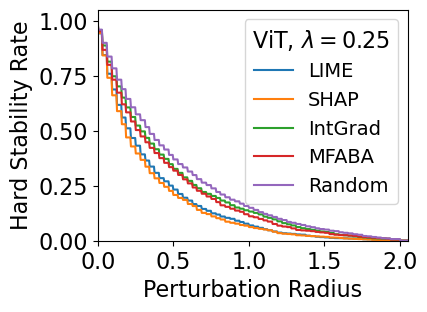

In [22]:
fig = plot_hard_rates_by_lambda(vit_hard_radii, "0.250", "ViT, $\lambda = 0.25$", xticks=[0, 0.5, 1.0, 1.5, 2.0])
fig.savefig("_dump/hard_vs_lambda_vit_imagenet_2_per_class_0.250_main_text.pdf", bbox_inches="tight")

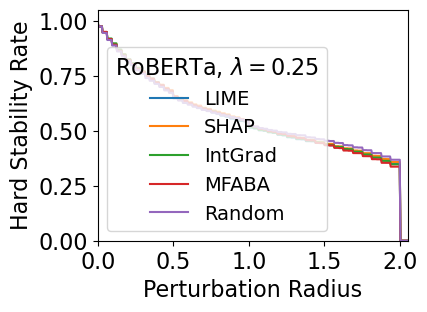

In [23]:
fig = plot_hard_rates_by_lambda(roberta_all_hard_radii, "0.250", "RoBERTa, $\lambda = 0.25$", xticks=[0, 0.5, 1.0, 1.5, 2.0])
fig.savefig("_dump/hard_vs_lambda_roberta_tweeteval_all_0.250_main_text.pdf", bbox_inches="tight")